https://py-eddy-tracker.readthedocs.io/en/stable/python_module/02_eddy_identification/pet_eddy_detection.html

Using subset of MIOST from: file:///Users/Gomez023/Postdoc/develop/FaSt-SWOT/SWOT/L4_data/MIOST/2025-02-10_SWOT_L4_MIOST_test02.ipynb

## To dos:
- [ ] maps
- [ ] automatization
- [ ] venv_05?

In [1]:
# _05

# venv_py_eddy_tracker # --> error in get_demo_path
# venv_py_eddy_tracker_02 --> v04


In [2]:
from datetime import datetime

from matplotlib import pyplot as plt
from numpy import arange

from py_eddy_tracker import data
from py_eddy_tracker.dataset.grid import RegularGridDataset

import cartopy.crs as ccrs

from py_eddy_tracker.observations.observation import EddiesObservations

from glob import glob
import os
import cartopy

In [3]:
lon_min_ax, lon_max_ax = -6., 9.
lat_min_ax, lat_max_ax = 35., 45.

def start_axes(title):
    fig = plt.figure(figsize=(13, 5))
    ax = fig.add_axes([0.03, 0.03, 0.90, 0.94])
    ax.set_xlim(lon_min_ax, lon_max_ax), ax.set_ylim(lat_min_ax, lat_max_ax)
    # ax.set_xlim(-6, 36.5), ax.set_ylim(30, 46)
    ax.set_aspect("equal")
    ax.set_title(title, weight="bold")
    return ax


def update_axes(ax, mappable=None):
    ax.grid()
    if mappable:
        plt.colorbar(mappable, cax=ax.figure.add_axes([0.94, 0.15, 0.01, 0.6]), extend='max') # original: [0.94, 0.05, 0.01, 0.9] # --> doesnt wotk:, shrink=.5)

In [4]:
lon_min_ax, lon_max_ax = -6., 9.
lat_min_ax, lat_max_ax = 35., 45.

def start_axes_map(title):
    fig = plt.figure(figsize=(11, 5))
    ax = fig.add_axes([0.03, 0.03, 0.90, 0.94], projection=ccrs.PlateCarree())

    ax.set_xlim(lon_min_ax, lon_max_ax), ax.set_ylim(lat_min_ax, lat_max_ax)
    # ax.set_xlim(-6, 36.5), ax.set_ylim(30, 46)
    ax.set_aspect("equal")
    ax.set_title(title, weight="bold")

    # Add coastlines and grid lines
    ax.coastlines()
    ax.add_feature(cartopy.feature.LAND, facecolor=cartopy.feature.COLORS['land'], zorder=2) #'k') #cartopy.feature.COLORS['land'])

    gl = ax.gridlines(draw_labels=True);     
    gl.top_labels = False; gl.right_labels = False

    return ax

# Params.

# Loading data:

In [5]:
indir_miost = "/Users/Gomez023/Nextcloud/Projects/FaSt-SWOT/Data/SWOT/ftp_aviso/swot_products/l4_karin_nadir/v2.0.1/miost/"
outdir = indir_miost + 'subset/'
# outname = "dt_global_allsat_phy_l4_20240401_sub.nc"

# FaSt_SWOT_meu not there.. should be in OSR10 ANYWAYS...

In [14]:
data_paths_all = sorted(glob(outdir + "dt_global_allsat_phy_l4_" + "202[3-4]" + "*_sub.nc"))
data_paths_all

['/Users/Gomez023/Nextcloud/Projects/FaSt-SWOT/Data/SWOT/ftp_aviso/swot_products/l4_karin_nadir/v2.0.1/miost/subset/dt_global_allsat_phy_l4_20230801_sub.nc',
 '/Users/Gomez023/Nextcloud/Projects/FaSt-SWOT/Data/SWOT/ftp_aviso/swot_products/l4_karin_nadir/v2.0.1/miost/subset/dt_global_allsat_phy_l4_20230802_sub.nc',
 '/Users/Gomez023/Nextcloud/Projects/FaSt-SWOT/Data/SWOT/ftp_aviso/swot_products/l4_karin_nadir/v2.0.1/miost/subset/dt_global_allsat_phy_l4_20230803_sub.nc',
 '/Users/Gomez023/Nextcloud/Projects/FaSt-SWOT/Data/SWOT/ftp_aviso/swot_products/l4_karin_nadir/v2.0.1/miost/subset/dt_global_allsat_phy_l4_20230804_sub.nc',
 '/Users/Gomez023/Nextcloud/Projects/FaSt-SWOT/Data/SWOT/ftp_aviso/swot_products/l4_karin_nadir/v2.0.1/miost/subset/dt_global_allsat_phy_l4_20230805_sub.nc',
 '/Users/Gomez023/Nextcloud/Projects/FaSt-SWOT/Data/SWOT/ftp_aviso/swot_products/l4_karin_nadir/v2.0.1/miost/subset/dt_global_allsat_phy_l4_20230806_sub.nc',
 '/Users/Gomez023/Nextcloud/Projects/FaSt-SWOT/Data/

In [15]:
len(data_paths_all)

488

In [12]:
# # should 335
# # augist, sept, oct, nov, dec,
# 31 + 30 +31 + 30 +31 
# # jan, feb, mar, apri, may, jue
# +31+29+31+30+31+30

In [11]:
31 + 30 +31 + 30 +31 +31+29+31+30+31+30

335

In [18]:
data_paths = data_paths_all[0:-153]
data_paths

['/Users/Gomez023/Nextcloud/Projects/FaSt-SWOT/Data/SWOT/ftp_aviso/swot_products/l4_karin_nadir/v2.0.1/miost/subset/dt_global_allsat_phy_l4_20230801_sub.nc',
 '/Users/Gomez023/Nextcloud/Projects/FaSt-SWOT/Data/SWOT/ftp_aviso/swot_products/l4_karin_nadir/v2.0.1/miost/subset/dt_global_allsat_phy_l4_20230802_sub.nc',
 '/Users/Gomez023/Nextcloud/Projects/FaSt-SWOT/Data/SWOT/ftp_aviso/swot_products/l4_karin_nadir/v2.0.1/miost/subset/dt_global_allsat_phy_l4_20230803_sub.nc',
 '/Users/Gomez023/Nextcloud/Projects/FaSt-SWOT/Data/SWOT/ftp_aviso/swot_products/l4_karin_nadir/v2.0.1/miost/subset/dt_global_allsat_phy_l4_20230804_sub.nc',
 '/Users/Gomez023/Nextcloud/Projects/FaSt-SWOT/Data/SWOT/ftp_aviso/swot_products/l4_karin_nadir/v2.0.1/miost/subset/dt_global_allsat_phy_l4_20230805_sub.nc',
 '/Users/Gomez023/Nextcloud/Projects/FaSt-SWOT/Data/SWOT/ftp_aviso/swot_products/l4_karin_nadir/v2.0.1/miost/subset/dt_global_allsat_phy_l4_20230806_sub.nc',
 '/Users/Gomez023/Nextcloud/Projects/FaSt-SWOT/Data/

In [19]:
outdir = "/Users/Gomez023/Nextcloud/Projects/OSR10/Data/outputs/eddy-tracker/"

In [20]:
import xarray as xr
xr.open_dataset(data_paths[0])

<xarray.Dataset>
Dimensions:           (time: 1, latitude: 88, longitude: 120, bounds: 2)
Coordinates:
  * longitude         (longitude) float32 -5.938 -5.812 -5.688 ... 8.812 8.938
  * latitude          (latitude) float32 34.06 34.19 34.31 ... 44.69 44.81 44.94
  * time              (time) datetime64[ns] 2023-08-01
    longitude_bounds  (longitude, bounds) float64 ...
    latitude_bounds   (latitude, bounds) float64 ...
Dimensions without coordinates: bounds
Data variables:
    sla               (time, latitude, longitude) float64 ...
    ugosa             (time, latitude, longitude) float64 ...
    vgosa             (time, latitude, longitude) float64 ...
    adt               (time, latitude, longitude) float64 ...
    ugos              (time, latitude, longitude) float64 ...
    vgos              (time, latitude, longitude) float64 ...
Attributes: (12/46)
    description:                      Miost analysis 
    Conventions:                     CF-1.6
    Metadata_Conventions:            Unidata Dataset Discovery v1.0
    cdm_data_type:                   Grid
    comment:                         Sea Surface Height measured by Altimetry...
    contact:                         
    ...                              ...
    time_coverage_duration:          P1D
    time_coverage_resolution:        P1D
    title:                           DT merged all satellites Global Ocean Gr...
    time_coverage_start:             2023-08-01T12:00:00Z
    time_coverage_end:               2023-08-01T12:00:00Z
    doi:                             10.24400/527896/a01-2025.001

# Monthly loop:

In [21]:
ds_miost = xr.open_dataset(data_paths[10])
ds_miost

<xarray.Dataset>
Dimensions:           (time: 1, latitude: 88, longitude: 120, bounds: 2)
Coordinates:
  * longitude         (longitude) float32 -5.938 -5.812 -5.688 ... 8.812 8.938
  * latitude          (latitude) float32 34.06 34.19 34.31 ... 44.69 44.81 44.94
  * time              (time) datetime64[ns] 2023-08-11
    longitude_bounds  (longitude, bounds) float64 ...
    latitude_bounds   (latitude, bounds) float64 ...
Dimensions without coordinates: bounds
Data variables:
    sla               (time, latitude, longitude) float64 ...
    ugosa             (time, latitude, longitude) float64 ...
    vgosa             (time, latitude, longitude) float64 ...
    adt               (time, latitude, longitude) float64 ...
    ugos              (time, latitude, longitude) float64 ...
    vgos              (time, latitude, longitude) float64 ...
Attributes: (12/46)
    description:                      Miost analysis 
    Conventions:                     CF-1.6
    Metadata_Conventions:            Unidata Dataset Discovery v1.0
    cdm_data_type:                   Grid
    comment:                         Sea Surface Height measured by Altimetry...
    contact:                         
    ...                              ...
    time_coverage_duration:          P1D
    time_coverage_resolution:        P1D
    title:                           DT merged all satellites Global Ocean Gr...
    time_coverage_start:             2023-08-01T12:00:00Z
    time_coverage_end:               2023-08-01T12:00:00Z
    doi:                             10.24400/527896/a01-2025.001

In [22]:
ds_miost.time.values[0]

numpy.datetime64('2023-08-11T00:00:00.000000000')

In [23]:
ds_miost.time.values[0].item()

1691712000000000000

--> The .item() method is converting to an int instead of a datetime, which means your numpy.datetime64 has no timezone/unit info that Python can map to a datetime object.

In [24]:
import pandas as pd

In [25]:
pd.Timestamp(ds_miost.time.values[0]).strftime('%Y%m%d')


'20230811'

In [26]:
from datetime import timedelta

def get_file_start_time(f):
    """Extract start datetime from SWOT filename."""
    basename = os.path.basename(f)
    # e.g. ...20230811T021853_20230811T031019...
    time_str = basename.split('_')[-3]  # '20230811T021853'
    return pd.to_datetime(time_str, format='%Y%m%dT%H%M%S')


In [27]:
ref_time = pd.Timestamp(ds_miost.time.values[0])
delta = timedelta(hours=12)


# matching_files = [# Ma
#     f for f in swot_files
#     if abs(get_file_start_time(f) - ref_time) <= delta
# ]

In [28]:
savedir = '/Users/Gomez023/Nextcloud/Projects/OSR10/Figures/vars_comp/MIOST-K_v201/'

## Plotting eddy centres:

We assume pixel position of grid is centered for /Users/Gomez023/Nextcloud/Projects/FaSt-SWOT/Data/SWOT/ftp_aviso/swot_products/l4_karin_nadir/v2.0.1/miost/subset/dt_global_allsat_phy_l4_20230812_sub.nc


File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'


/Users/Gomez023/Nextcloud/Projects/OSR10/Data/outputs/eddy-tracker/a_MIOST_v2.0.1_20230812.nc


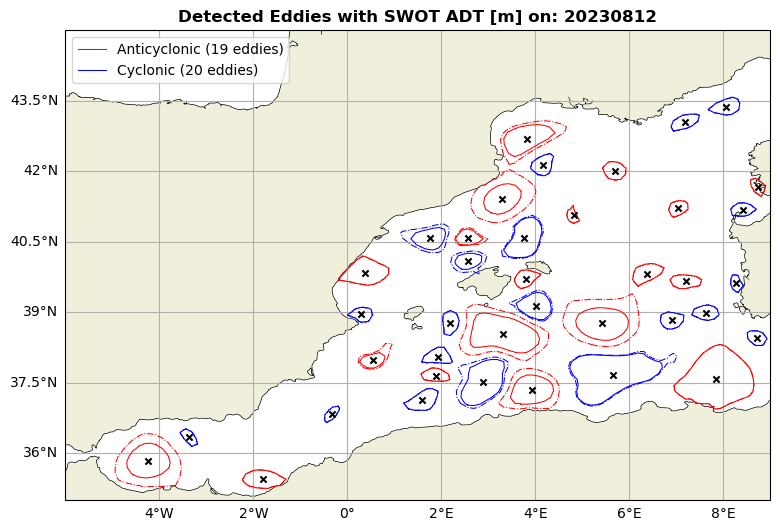

In [29]:
data_path = data_paths[11]
ds_miost = xr.open_dataset(data_path)

# # SWOT files
# ref_time = pd.Timestamp(ds_miost.time.values[0])
# print('ref time: ', ref_time)
# delta = timedelta(hours=12)

# swot_matching_files = [
#     f for f in swot_files
#     if abs(get_file_start_time(f) - ref_time) <= delta
# ]

# print(swot_matching_files)

# date for eddy id:
date = pd.Timestamp(ds_miost.time.values[0]).strftime('%Y%m%d')
# datetime(int(data_path[-15:-11]), int(data_path[-11:-9]), int(data_path[-9:-7]))

g = RegularGridDataset(data_path, "longitude", "latitude")
g.add_uv("adt")
g.bessel_high_filter("adt", 500)

a_name = outdir + 'a_MIOST_v2.0.1_' + date + '.nc'
c_name = outdir + 'c_MIOST_v2.0.1_' + date + '.nc'
print(a_name)
# a_name = '/Users/Gomez023/Nextcloud/Projects/OSR10/Data/outputs/eddy-tracker/a_MIOST_v2.0.1_20230811.nc'
# c_name = '/Users/Gomez023/Nextcloud/Projects/OSR10/Data/outputs/eddy-tracker/c_MIOST_v2.0.1_20230811.nc'
a = EddiesObservations.load_file(a_name)
c = EddiesObservations.load_file(c_name)

########
# Subplot 1
ax = start_axes_map("Detected Eddies with SWOT ADT [m] on: " + date)
ax.set_xlim(-6, 9), ax.set_ylim(35., 45.)

# swot_pass_times = []
# for swot_file in swot_matching_files:
#     ds_sw = xr.open_dataset(swot_file)

#     # Masking NATL
#     ds_sw = ds_sw.where(~((ds_sw.longitude < 0.) & (ds_sw.latitude > 43.))) 
    
#     m = ax.scatter(ds_sw.longitude, ds_sw.latitude, c=ds_sw.ssha_filtered+ds_sw.mdt, s=2
#                     , vmin = -0.15, vmax = 0.15 
#                     , transform=ccrs.PlateCarree(), cmap='RdBu_r') #  ,
#     swot_pass_times.append(pd.to_datetime(ds_sw.time.mean().values).strftime('%d/%m/%y %H:%M'))

# update_axes(ax, m)
# contours
a.display(
    ax, color="r", linewidth=0.75, label="Anticyclonic ({nb_obs} eddies)", ref=-10, transform=ccrs.PlateCarree()
)
c.display(
    ax, color="b", linewidth=0.75, label="Cyclonic ({nb_obs} eddies)", ref=-10, transform=ccrs.PlateCarree()
)
ax.legend(loc=2)
update_axes(ax)

# Eddy centers
ax.scatter(
    a.longitude,
    a.latitude,
    s=20,
    c="k",
    marker="x",
    label="Eddy center",
    zorder=10,
)

ax.scatter(
    c.longitude,
    c.latitude,
    s=20,
    c="k",
    marker="x",
    label="Eddy center",
    zorder=10,
)

######
# swot_info = '\n'.join(
#     f"Pass: {ff.split('/')[-1].split('_')[7]} at: {tt}"
#     for ff, tt in zip(swot_matching_files, swot_pass_times)
# )
# if not swot_info:
#     swot_info = 'No SWOT pass'

# ax.text(0.02, 0.8, swot_info, transform=ax.transAxes,
#     fontsize=12, weight='bold', va='top', ha='left',
#     bbox=dict(facecolor='wheat', alpha=0.7, edgecolor='none'))

plt.show()    


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [30]:
data_path = data_paths[0]
ds_miost = xr.open_dataset(data_path)

# print(swot_matching_files)

# date for eddy id:
date = pd.Timestamp(ds_miost.time.values[0]).strftime('%Y%m%d')
# datetime(int(data_path[-15:-11]), int(data_path[-11:-9]), int(data_path[-9:-7]))

g = RegularGridDataset(data_path, "longitude", "latitude")
g.add_uv("adt")
g.bessel_high_filter("adt", 500)

a_name = outdir + 'a_MIOST_v2.0.1_' + date + '.nc'
c_name = outdir + 'c_MIOST_v2.0.1_' + date + '.nc'
print(a_name)

all_a_m = EddiesObservations.load_file(a_name)
all_c_m = EddiesObservations.load_file(c_name)


We assume pixel position of grid is centered for /Users/Gomez023/Nextcloud/Projects/FaSt-SWOT/Data/SWOT/ftp_aviso/swot_products/l4_karin_nadir/v2.0.1/miost/subset/dt_global_allsat_phy_l4_20230801_sub.nc
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'


/Users/Gomez023/Nextcloud/Projects/OSR10/Data/outputs/eddy-tracker/a_MIOST_v2.0.1_20230801.nc


In [31]:
for data_path in data_paths[1::]:
    ds_miost = xr.open_dataset(data_path)

    # print(swot_matching_files)

    # date for eddy id:
    date = pd.Timestamp(ds_miost.time.values[0]).strftime('%Y%m%d')
    # datetime(int(data_path[-15:-11]), int(data_path[-11:-9]), int(data_path[-9:-7]))
    
    g = RegularGridDataset(data_path, "longitude", "latitude")
    g.add_uv("adt")
    g.bessel_high_filter("adt", 500)

    a_name = outdir + 'a_MIOST_v2.0.1_' + date + '.nc'
    c_name = outdir + 'c_MIOST_v2.0.1_' + date + '.nc'
    print(a_name)
    # a_name = '/Users/Gomez023/Nextcloud/Projects/OSR10/Data/outputs/eddy-tracker/a_MIOST_v2.0.1_20230811.nc'
    # c_name = '/Users/Gomez023/Nextcloud/Projects/OSR10/Data/outputs/eddy-tracker/c_MIOST_v2.0.1_20230811.nc'
    a = EddiesObservations.load_file(a_name)
    c = EddiesObservations.load_file(c_name)

    all_a_m = all_a_m.merge(a)
    all_c_m = all_c_m.merge(c)

We assume pixel position of grid is centered for /Users/Gomez023/Nextcloud/Projects/FaSt-SWOT/Data/SWOT/ftp_aviso/swot_products/l4_karin_nadir/v2.0.1/miost/subset/dt_global_allsat_phy_l4_20230802_sub.nc
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
We assume pixel position of grid is centered for /Users/Gomez023/Nextcloud/Projects/FaSt-SWOT/Data/SWOT/ftp_aviso/swot_products/l4_karin_nadir/v2.0.1/miost/subset/dt_global_allsat_phy_l4_20230803_sub.nc


/Users/Gomez023/Nextcloud/Projects/OSR10/Data/outputs/eddy-tracker/a_MIOST_v2.0.1_20230802.nc


File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
We assume pixel position of grid is centered for /Users/Gomez023/Nextcloud/Projects/FaSt-SWOT/Data/SWOT/ftp_aviso/swot_products/l4_karin_nadir/v2.0.1/miost/subset/dt_global_allsat_phy_l4_20230804_sub.nc


/Users/Gomez023/Nextcloud/Projects/OSR10/Data/outputs/eddy-tracker/a_MIOST_v2.0.1_20230803.nc


File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
We assume pixel position of grid is centered for /Users/Gomez023/Nextcloud/Projects/FaSt-SWOT/Data/SWOT/ftp_aviso/swot_products/l4_karin_nadir/v2.0.1/miost/subset/dt_global_allsat_phy_l4_20230805_sub.nc


...

/Users/Gomez023/Nextcloud/Projects/OSR10/Data/outputs/eddy-tracker/a_MIOST_v2.0.1_20240627.nc


We assume pixel position of grid is centered for /Users/Gomez023/Nextcloud/Projects/FaSt-SWOT/Data/SWOT/ftp_aviso/swot_products/l4_karin_nadir/v2.0.1/miost/subset/dt_global_allsat_phy_l4_20240629_sub.nc


/Users/Gomez023/Nextcloud/Projects/OSR10/Data/outputs/eddy-tracker/a_MIOST_v2.0.1_20240628.nc


We assume pixel position of grid is centered for /Users/Gomez023/Nextcloud/Projects/FaSt-SWOT/Data/SWOT/ftp_aviso/swot_products/l4_karin_nadir/v2.0.1/miost/subset/dt_global_allsat_phy_l4_20240630_sub.nc


/Users/Gomez023/Nextcloud/Projects/OSR10/Data/outputs/eddy-tracker/a_MIOST_v2.0.1_20240629.nc
/Users/Gomez023/Nextcloud/Projects/OSR10/Data/outputs/eddy-tracker/a_MIOST_v2.0.1_20240630.nc


https://py-eddy-tracker.readthedocs.io/en/stable/python_module/02_eddy_identification/pet_statistics_on_identification.html#sphx-glr-python-module-02-eddy-identification-pet-statistics-on-identification-py

In [32]:
all_a_m.nb_days # should be 335

335.0

**From 01/08/2023 to 30/11/2024, inclusive, there are 488 days.**

# Laoding DUACS:

In [33]:
indir_duacs_nrt = "/Users/Gomez023/Nextcloud/Projects/OSR10/Data/CMS/Europe/NRT/subset/"

data_paths_DUACS_NRT_all = sorted(glob(indir_duacs_nrt + "wmed_cmems_obs-sl_eur_phy-ssh_nrt_allsat-l4-duacs-0.125deg_P1D_" + "202[3-4]" + "*_sub.nc"))


In [35]:
data_paths_DUACS_NRT = data_paths_DUACS_NRT_all[0:-148]
data_paths_DUACS_NRT

['/Users/Gomez023/Nextcloud/Projects/OSR10/Data/CMS/Europe/NRT/subset/wmed_cmems_obs-sl_eur_phy-ssh_nrt_allsat-l4-duacs-0.125deg_P1D_20230801_sub.nc',
 '/Users/Gomez023/Nextcloud/Projects/OSR10/Data/CMS/Europe/NRT/subset/wmed_cmems_obs-sl_eur_phy-ssh_nrt_allsat-l4-duacs-0.125deg_P1D_20230802_sub.nc',
 '/Users/Gomez023/Nextcloud/Projects/OSR10/Data/CMS/Europe/NRT/subset/wmed_cmems_obs-sl_eur_phy-ssh_nrt_allsat-l4-duacs-0.125deg_P1D_20230803_sub.nc',
 '/Users/Gomez023/Nextcloud/Projects/OSR10/Data/CMS/Europe/NRT/subset/wmed_cmems_obs-sl_eur_phy-ssh_nrt_allsat-l4-duacs-0.125deg_P1D_20230804_sub.nc',
 '/Users/Gomez023/Nextcloud/Projects/OSR10/Data/CMS/Europe/NRT/subset/wmed_cmems_obs-sl_eur_phy-ssh_nrt_allsat-l4-duacs-0.125deg_P1D_20230805_sub.nc',
 '/Users/Gomez023/Nextcloud/Projects/OSR10/Data/CMS/Europe/NRT/subset/wmed_cmems_obs-sl_eur_phy-ssh_nrt_allsat-l4-duacs-0.125deg_P1D_20230806_sub.nc',
 '/Users/Gomez023/Nextcloud/Projects/OSR10/Data/CMS/Europe/NRT/subset/wmed_cmems_obs-sl_eur_ph

In [36]:
a_names_DUACS_NRT = []
c_names_DUACS_NRT = []

for data_path_DUACS_NRT in data_paths_DUACS_NRT:
   date = datetime(int(data_path_DUACS_NRT[-15:-11]), int(data_path_DUACS_NRT[-11:-9]),
                int(data_path_DUACS_NRT[-9:-7]))
   print(date)
   
   a_name_DUACS_NRT = outdir + 'a_DUACS-NRT_' + date.strftime('%Y%m%d') + '.nc'
   c_name_DUACS_NRT = outdir + 'c_DUACS-NRT_' + date.strftime('%Y%m%d') + '.nc'
   
   a_names_DUACS_NRT.append(a_name_DUACS_NRT)
   c_names_DUACS_NRT.append(c_name_DUACS_NRT)

2023-08-01 00:00:00
2023-08-02 00:00:00
2023-08-03 00:00:00
2023-08-04 00:00:00
2023-08-05 00:00:00
2023-08-06 00:00:00
2023-08-07 00:00:00
2023-08-08 00:00:00
2023-08-09 00:00:00
2023-08-10 00:00:00
2023-08-11 00:00:00
2023-08-12 00:00:00
2023-08-13 00:00:00
2023-08-14 00:00:00
2023-08-15 00:00:00
2023-08-16 00:00:00
2023-08-17 00:00:00
2023-08-18 00:00:00
2023-08-19 00:00:00
2023-08-20 00:00:00
2023-08-21 00:00:00
2023-08-22 00:00:00
2023-08-23 00:00:00
2023-08-24 00:00:00
2023-08-25 00:00:00
2023-08-26 00:00:00
2023-08-27 00:00:00
2023-08-28 00:00:00
2023-08-29 00:00:00
2023-08-30 00:00:00
2023-08-31 00:00:00
2023-09-01 00:00:00
2023-09-02 00:00:00
2023-09-03 00:00:00
2023-09-04 00:00:00
2023-09-05 00:00:00
2023-09-06 00:00:00
2023-09-07 00:00:00
2023-09-08 00:00:00
2023-09-09 00:00:00
2023-09-10 00:00:00
2023-09-11 00:00:00
2023-09-12 00:00:00
2023-09-13 00:00:00
2023-09-14 00:00:00
2023-09-15 00:00:00
2023-09-16 00:00:00
2023-09-17 00:00:00
2023-09-18 00:00:00
2023-09-19 00:00:00


# remove error days DUACS-OI:

In [37]:
a_err_231109 = "/Users/Gomez023/Nextcloud/Projects/OSR10/Data/outputs/eddy-tracker/a_DUACS-NRT_20231109.nc"
a_err_231111 = "/Users/Gomez023/Nextcloud/Projects/OSR10/Data/outputs/eddy-tracker/a_DUACS-NRT_20231111.nc"

c_err_231109 = "/Users/Gomez023/Nextcloud/Projects/OSR10/Data/outputs/eddy-tracker/c_DUACS-NRT_20231109.nc"
c_err_231111 = "/Users/Gomez023/Nextcloud/Projects/OSR10/Data/outputs/eddy-tracker/c_DUACS-NRT_20231111.nc"

In [38]:
# Remove the unwanted files from the list
a_names_DUACS_NRT = [
    f for f in a_names_DUACS_NRT
    if f not in [a_err_231109, a_err_231111]
]

In [39]:
# Remove the unwanted files from the list
c_names_DUACS_NRT = [
    f for f in c_names_DUACS_NRT
    if f not in [c_err_231109, c_err_231111]
]

# Load eddy data:

In [40]:

all_a_DUACS_NRT = EddiesObservations.concatenate(
    [EddiesObservations.load_file(ff) for ff in a_names_DUACS_NRT]
)

File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'


File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but softwa

In [41]:

all_c_DUACS_NRT = EddiesObservations.concatenate(
    [EddiesObservations.load_file(ff) for ff in c_names_DUACS_NRT]
)

File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but softwa

In [40]:

# # EKE_a_mean_m = []
# eke_merged_m_mean = []
# eke_merged_d_mean = []
# eke_merged_m_max = []
# eke_merged_d_max = []

# for ii in range(0, len(a_names_DUACS_NRT)):
#     ff_a_m = EddiesObservations.load_file(a_names_MIOST_v201[ii])
#     ff_c_m = EddiesObservations.load_file(c_names_MIOST_v201[ii])

#     if (a_names_DUACS_NRT[ii] == a_err_231109) | ((a_names_DUACS_NRT[ii] == a_err_231111)):
#         eke_merged_m_mean_daily_mean = np.nan # cannot have data for MIOST either as we are matching the eddies
#         eke_merged_d_mean_daily_mean = np.nan
#         eke_merged_m_max_daily_mean  = np.nan
#         eke_merged_d_max_daily_mean  = np.nan
#     else:
#         ff_a_d = EddiesObservations.load_file(a_names_DUACS_NRT[ii])
#         ff_c_d = EddiesObservations.load_file(c_names_DUACS_NRT[ii])

#         # Merge:
#         merge_m_ = ff_a_m.merge(ff_c_m)
#         merge_d_ = ff_a_d.merge(ff_c_d)


In [42]:
lon_min_ax, lon_max_ax = -6., 9.
lat_min_ax, lat_max_ax = 35., 45.

def start_axes_map_subplots(title, nax): 
    """
    title = "xx ()"
    nax, e.g. 121
    """
    # plt.figure(figsize=(14,5)) #(17,5)
    ax = plt.subplot(nax, projection=ccrs.PlateCarree())
    # ax = fig.add_axes([0.03, 0.03, 0.90, 0.94], projection=ccrs.PlateCarree())
    ax.add_feature(cartopy.feature.LAND, facecolor=cartopy.feature.COLORS['land'], zorder=2) #'k') #cartopy.feature.COLORS['land'])

    ax.set_xlim(lon_min_ax, lon_max_ax), ax.set_ylim(lat_min_ax, lat_max_ax)
    # ax.set_xlim(-6, 36.5), ax.set_ylim(30, 46)
    ax.set_aspect("equal")
    ax.set_title(title, weight="bold")

    # Add coastlines and grid lines
    ax.coastlines()
    gl = ax.gridlines(draw_labels=True);     
    gl.top_labels = False; gl.right_labels = False

    return ax

# Plots:

In [ ]:
# plt.figure(figsize=(14,5))
# ax = start_axes_map_subplots("(A) Detected Eddies DUACS-OI 02/24", 121) #  NRT
# ax.set_xlim(-6, 9), ax.set_ylim(35., 45.)

# all_a_DUACS_NRT.display(ax, color="C3", linewidth=0.75, label="Anticyclonic ({nb_obs} eddies)", ref=-10, transform=ccrs.PlateCarree(), alpha=.5)
# all_c_DUACS_NRT.display(ax, color="C0", linewidth=0.75, label="Cyclonic ({nb_obs} eddies)", ref=-10, transform=ccrs.PlateCarree(), alpha=.5)

# ax.legend(loc=2)
# update_axes(ax)

# ax = start_axes_map_subplots("(B) Detected Eddies MIOST-K 02/24", 122) #  v2.0.1
# ax.set_xlim(-6, 9), ax.set_ylim(35., 45.)

# all_a_MIOST.display(ax, color="C3", linewidth=0.75, label="Anticyclonic ({nb_obs} eddies)", ref=-10, transform=ccrs.PlateCarree(), alpha=.5)
# all_c_MIOST.display(ax, color="C0", linewidth=0.75, label="Cyclonic ({nb_obs} eddies)", ref=-10, transform=ccrs.PlateCarree(), alpha=.5)

# ax.legend(loc=2)
# update_axes(ax)
# # ndate = a_name_MIOST_v201.split('/')[-1].split('_')[-1].split('.')[0]
# # plt.suptitle("Detected Eddies on " + ndate)

/Users/Gomez023/src/git/paper-OSR10_Gomez-Navarro_etal_2026/fig03.ipynb --> grispec plots here

# With Map; and using center=True:

In [43]:
# Count pixel encompassed in each contour
step = 1 # degrees
g_a_m = all_a_m.grid_count(bins=((-10, 37, step), (30, 46, step)), center=True)
g_c_m = all_c_m.grid_count(bins=((-10, 37, step), (30, 46, step)), center=True)

g_a_d = all_a_DUACS_NRT.grid_count(bins=((-10, 37, step), (30, 46, step)), center=True)
g_c_d = all_c_DUACS_NRT.grid_count(bins=((-10, 37, step), (30, 46, step)), center=True)

## Anticyclones:

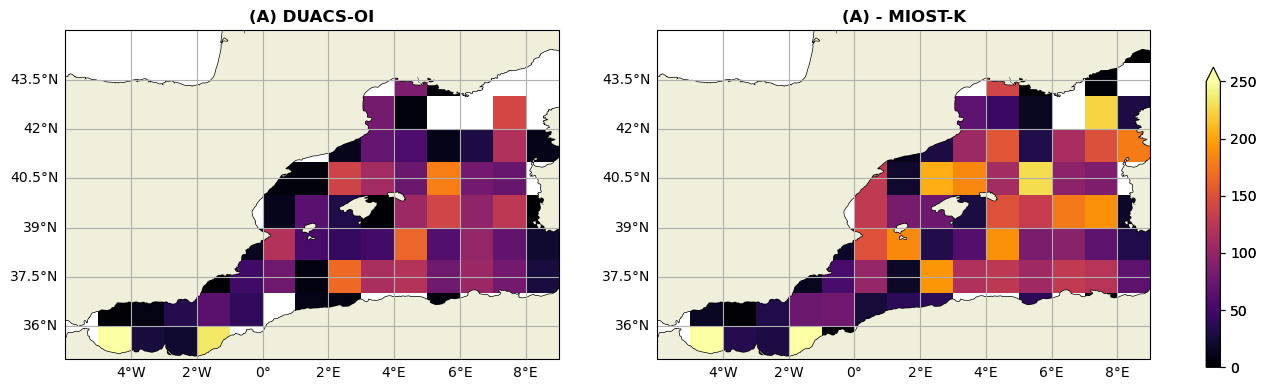

In [44]:
plt.figure(figsize=(14,5))
ax = start_axes_map_subplots("(A) DUACS-OI", 121) #  NRT
ax.set_xlim(-6, 9), ax.set_ylim(35., 45.)

# without factor: factor=1 / all_a.nb_days, 
m = g_a_d.display(
    ax, cmap="inferno", name="count", vmin=0, vmax=250, transform=ccrs.PlateCarree() #terrain_r vmax=0.75, 
)

update_axes(ax, m)

ax = start_axes_map_subplots("(A) - MIOST-K", 122) #  NRT
ax.set_xlim(-6, 9), ax.set_ylim(35., 45.)

# without factor: factor=1 / all_a.nb_days, 
m = g_a_m.display(
    ax, cmap="inferno", name="count", vmin=0, vmax=250, transform=ccrs.PlateCarree() #terrain_r vmax=0.75, 
)

update_axes(ax, m)


## Cyclones:

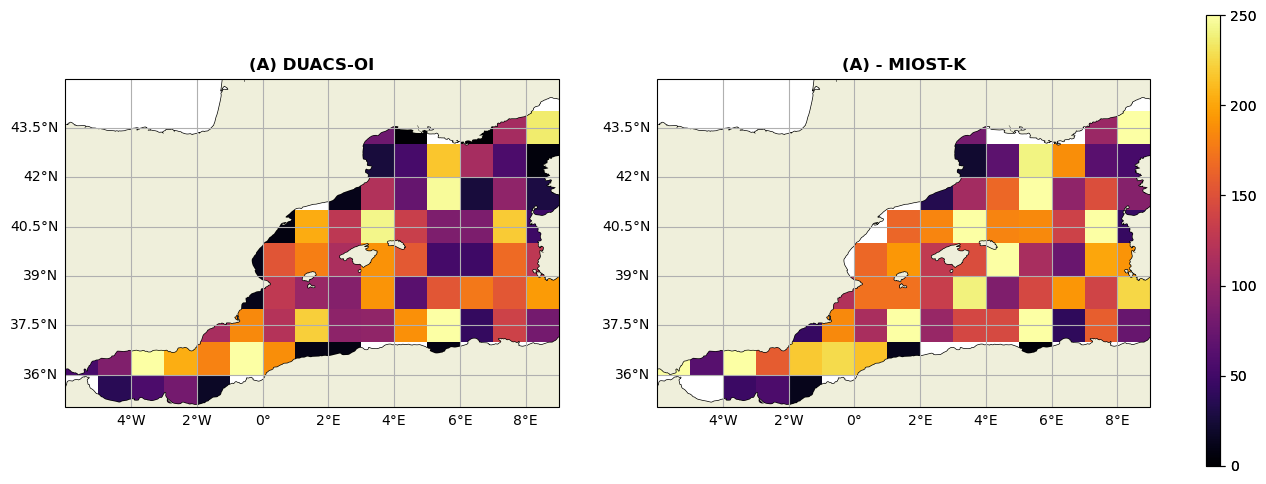

In [45]:
plt.figure(figsize=(14,5))
ax = start_axes_map_subplots("(A) DUACS-OI", 121) #  NRT
ax.set_xlim(-6, 9), ax.set_ylim(35., 45.)

# without factor: factor=1 / all_a.nb_days, 
m = g_c_d.display(
    ax, cmap="inferno", name="count", vmin=0, vmax=250, transform=ccrs.PlateCarree() #terrain_r vmax=0.75, 
)

update_axes(ax, m)

ax = start_axes_map_subplots("(A) - MIOST-K", 122) #  NRT
ax.set_xlim(-6, 9), ax.set_ylim(35., 45.)

# without factor: factor=1 / all_a.nb_days, 
m = g_c_m.display(
    ax, cmap="inferno", name="count", vmin=0, vmax=250, transform=ccrs.PlateCarree() #terrain_r vmax=0.75, 
)

update_axes(ax, m)


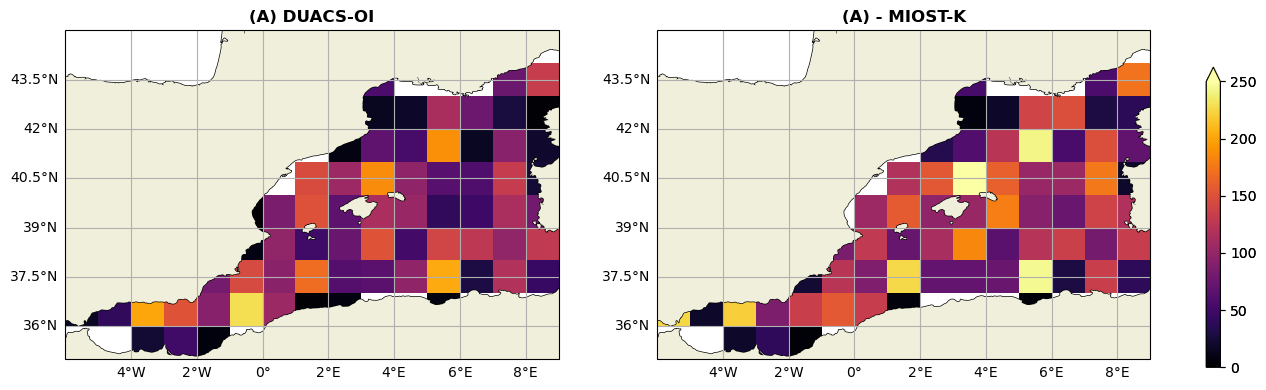

In [45]:
plt.figure(figsize=(14,5))
ax = start_axes_map_subplots("(A) DUACS-OI", 121) #  NRT
ax.set_xlim(-6, 9), ax.set_ylim(35., 45.)

# without factor: factor=1 / all_a.nb_days, 
m = g_c_d.display(
    ax, cmap="inferno", name="count", vmin=0, vmax=250, transform=ccrs.PlateCarree() #terrain_r vmax=0.75, 
)

update_axes(ax, m)

ax = start_axes_map_subplots("(A) - MIOST-K", 122) #  NRT
ax.set_xlim(-6, 9), ax.set_ylim(35., 45.)

# without factor: factor=1 / all_a.nb_days, 
m = g_c_m.display(
    ax, cmap="inferno", name="count", vmin=0, vmax=250, transform=ccrs.PlateCarree() #terrain_r vmax=0.75, 
)

update_axes(ax, m)


# Merging eddies:

In [46]:
all_e_m = all_c_m.merge(all_a_m)
all_e_d = all_c_DUACS_NRT.merge(all_a_DUACS_NRT)

In [47]:
all_e_m.shape

(13206,)

In [48]:
(all_e_d.shape)

(9701,)

# instead of inter=True, that is wrt to contours, using center=True that is wrt to eddy center:

In [49]:
# Count pixel encompassed in each contour
step = 1 # degrees
g_e_m = all_e_m.grid_count(bins=((-10, 37, step), (30, 46, step)), center=True)
g_e_d = all_e_d.grid_count(bins=((-10, 37, step), (30, 46, step)), center=True)


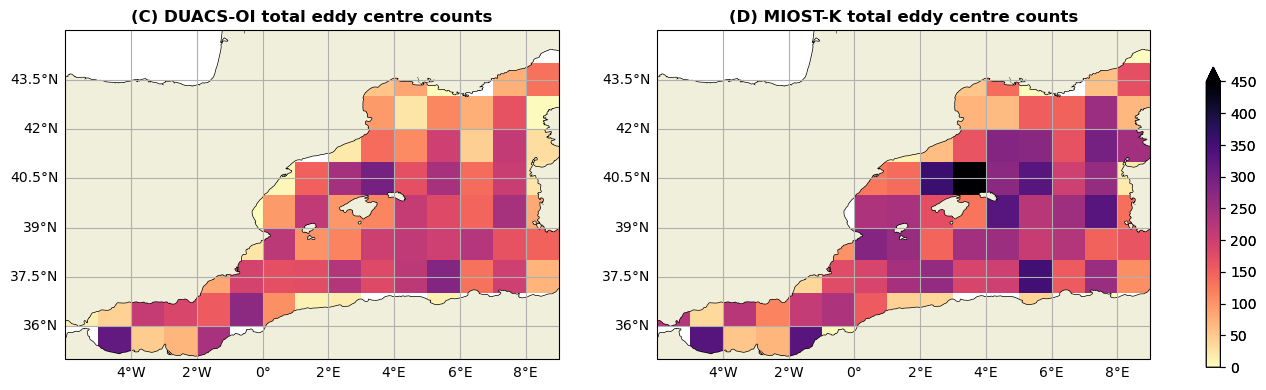

In [50]:
plt.figure(figsize=(14,5))
ax = start_axes_map_subplots("(C) DUACS-OI total eddy centre counts", 121) #  NRT
ax.set_xlim(-6, 9), ax.set_ylim(35., 45.)

# without factor: factor=1 / all_a.nb_days, 
m = g_e_d.display(
    ax, cmap="magma_r", name="count", vmin=0, vmax=450, transform=ccrs.PlateCarree() #terrain_r vmax=0.75, 
)

update_axes(ax, m)

ax = start_axes_map_subplots("(D) MIOST-K total eddy centre counts", 122) #  NRT
ax.set_xlim(-6, 9), ax.set_ylim(35., 45.)

m = g_e_m.display(
    ax, cmap="magma_r", name="count", vmin=0, vmax=450, transform=ccrs.PlateCarree() #terrain_r vmax=0.75, 
)

update_axes(ax, m)
# cmap="inferno before",

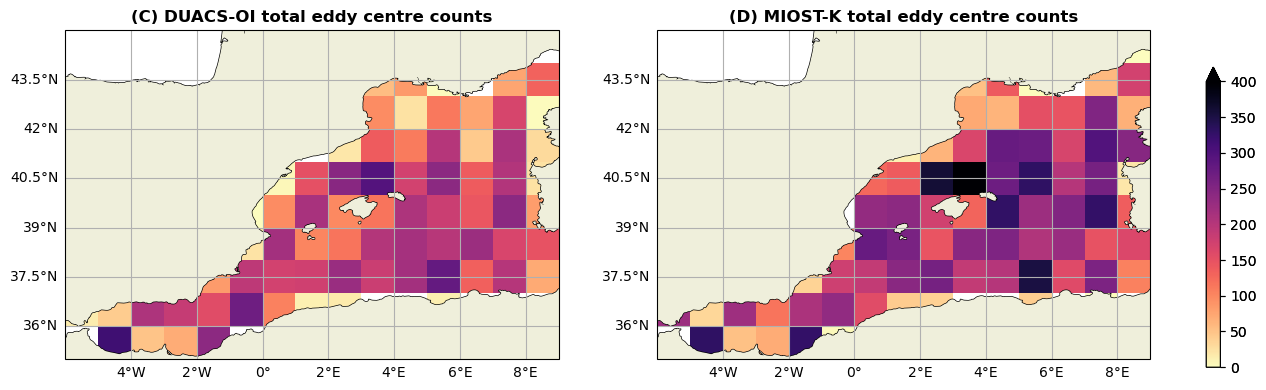

In [51]:
plt.figure(figsize=(14,5))
ax = start_axes_map_subplots("(C) DUACS-OI total eddy centre counts", 121) #  NRT
ax.set_xlim(-6, 9), ax.set_ylim(35., 45.)

# without factor: factor=1 / all_a.nb_days, 
m = g_e_d.display(
    ax, cmap="magma_r", name="count", vmin=0, vmax=400, transform=ccrs.PlateCarree() #terrain_r vmax=0.75, 
)

update_axes(ax, m)

ax = start_axes_map_subplots("(D) MIOST-K total eddy centre counts", 122) #  NRT
ax.set_xlim(-6, 9), ax.set_ylim(35., 45.)

m = g_e_m.display(
    ax, cmap="magma_r", name="count", vmin=0, vmax=400, transform=ccrs.PlateCarree() #terrain_r vmax=0.75, 
)

update_axes(ax, m)
# cmap="inferno before",

# Difference?